In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import re

def cargar_100_procesos(nombre_archivo):
    datos = []
    with open(nombre_archivo, 'r') as f:
        contenido = f.read()
        numeros = re.findall(r'\d+', contenido)
        for i in range(0, len(numeros), 4):
            if i + 3 < len(numeros):
                datos.append([int(numeros[i]), int(numeros[i+1]), 
                              int(numeros[i+2]), int(numeros[i+3])])
    df = pd.DataFrame(datos, columns=['id', 'arrival', 'burst', 'priority'])
    return df

def simular_loteria(df_proc):
    random.seed(42)
    n = len(df_proc)
    procesos = df_proc.copy()
    procesos['finished'] = False
    procesos['start_time'] = -1
    procesos['finish_time'] = 0
    procesos['waiting_time'] = 0
    procesos['turnaround'] = 0
    procesos['response_time'] = -1
    
    tiempo_actual = 0
    completados = 0
    max_p = procesos['priority'].max()
    
    while completados < n:
        listos = procesos[(procesos['arrival'] <= tiempo_actual) & (procesos['finished'] == False)].copy()
        if listos.empty:
            tiempo_actual = procesos[procesos['finished'] == False]['arrival'].min()
            continue
        
        listos['tickets'] = (max_p - listos['priority'] + 1) * 10
        total_tickets = listos['tickets'].sum()
        
        ganador_val = random.randint(1, total_tickets)
        suma_acum = 0
        id_ganador = -1
        for _, row in listos.iterrows():
            suma_acum += row['tickets']
            if ganador_val <= suma_acum:
                id_ganador = row['id']
                break
        
        idx = procesos[procesos['id'] == id_ganador].index[0]
        if procesos.at[idx, 'start_time'] == -1:
            procesos.at[idx, 'start_time'] = tiempo_actual
            procesos.at[idx, 'response_time'] = tiempo_actual - procesos.at[idx, 'arrival']
        
        rafaga = procesos.at[idx, 'burst']
        tiempo_actual += rafaga
        procesos.at[idx, 'finish_time'] = tiempo_actual
        procesos.at[idx, 'turnaround'] = tiempo_actual - procesos.at[idx, 'arrival']
        procesos.at[idx, 'waiting_time'] = procesos.at[idx, 'turnaround'] - rafaga
        procesos.at[idx, 'finished'] = True
        completados += 1
    return procesos

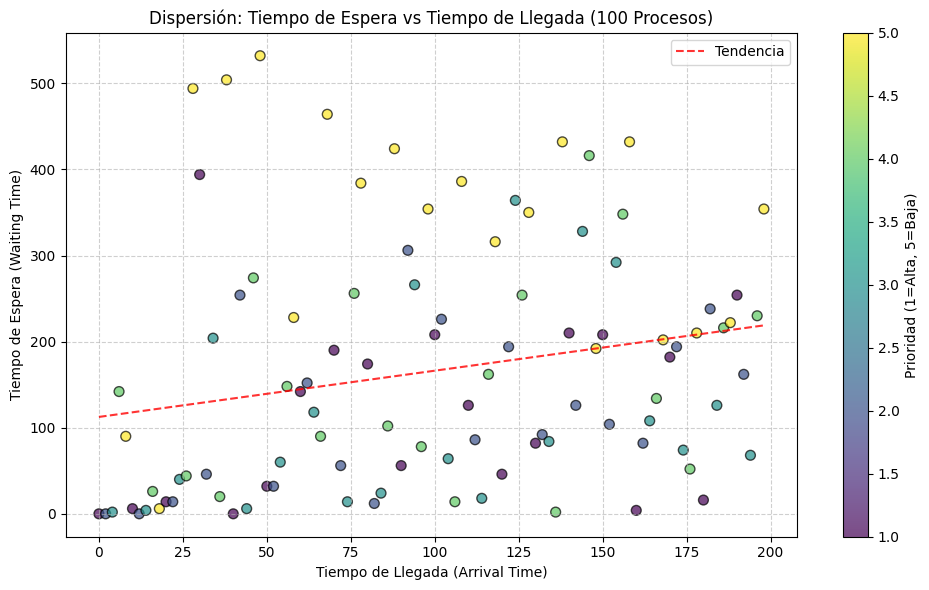

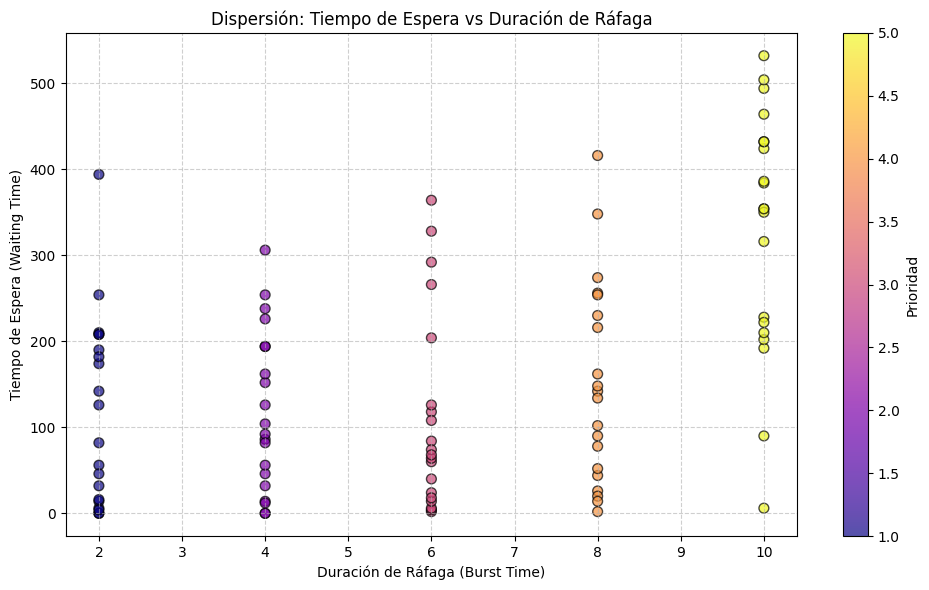

In [9]:
# Ejecución
df = cargar_100_procesos('Procesos.txt')
resultados = simular_loteria(df)

# Gráfico de dispersión (Scatter Plot)
plt.figure(figsize=(10, 6))
# Usamos el tiempo de llegada en X y el tiempo de espera en Y
# El color representa la prioridad (1 es alta, 5 es baja)
scatter = plt.scatter(resultados['arrival'], resultados['waiting_time'], 
                      c=resultados['priority'], cmap='viridis', s=50, edgecolors='black', alpha=0.7)

plt.colorbar(scatter, label='Prioridad (1=Alta, 5=Baja)')
plt.xlabel('Tiempo de Llegada (Arrival Time)')
plt.ylabel('Tiempo de Espera (Waiting Time)')
plt.title('Dispersión: Tiempo de Espera vs Tiempo de Llegada (100 Procesos)')
plt.grid(True, linestyle='--', alpha=0.6)

# Añadir una línea de tendencia simple para ver si la espera aumenta con el tiempo
import numpy as np
z = np.polyfit(resultados['arrival'], resultados['waiting_time'], 1)
p = np.poly1d(z)
plt.plot(resultados['arrival'], p(resultados['arrival']), "r--", alpha=0.8, label='Tendencia')

plt.legend()
plt.tight_layout()
plt.savefig('dispersion_espera.png')

# Otro gráfico: Ráfaga vs Espera
plt.figure(figsize=(10, 6))
scatter2 = plt.scatter(resultados['burst'], resultados['waiting_time'], 
                       c=resultados['priority'], cmap='plasma', s=50, edgecolors='black', alpha=0.7)
plt.colorbar(scatter2, label='Prioridad')
plt.xlabel('Duración de Ráfaga (Burst Time)')
plt.ylabel('Tiempo de Espera (Waiting Time)')
plt.title('Dispersión: Tiempo de Espera vs Duración de Ráfaga')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('dispersion_rafaga.png')